# 01 - EDA & Audit Dataset (Tugas 2)

Notebook ini mengaudit data Tugas 1 yang dipakai untuk eksperimen Tugas 2:

- **Input kurs**: `data/aligned/daily_aligned_dataset.csv` (JISDOR BI).
- **Input berita**: `data/cleaned/news_cleaned.csv` + `data/aligned/news_alignment.csv` (14.941 artikel geopolitik CNBC).
- **Target**: arah kurs hari perdagangan berikutnya (`target_next_up`), flat dihitung 0.

Fokus audit: rentang tanggal, nilai hilang, duplikat, coverage berita vs hari perdagangan, dan kesiapan split kronologis.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import config, data_preparation
from src.config import DAILY_ALIGNED_CSV, FIGURES_DIR, NEWS_ALIGNMENT_CSV

pd.set_option("display.max_columns", 50)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("root:", ROOT)

root: C:\Users\Satya\Desktop\tugas 1 NLP\NLP-Project


## 1. Audit berkas dan kolom

Ringkasan di bawah dihitung oleh `src.data_preparation.audit_dataset()` (tersimpan juga di `data/processed/audit_summary.json`).

In [2]:
audit = data_preparation.audit_dataset()
print(json.dumps(audit["exchange_rate"], indent=2, ensure_ascii=False))
print(json.dumps(audit["news"], indent=2, ensure_ascii=False))
print(json.dumps(audit["alignment"]["articles_per_trading_day"], indent=2, ensure_ascii=False))

{
  "rows": 1202,
  "date_start": "2021-09-01",
  "date_end": "2026-09-01",
  "columns": [
    "trading_date",
    "usd_idr_rate",
    "previous_rate",
    "rate_change",
    "daily_return",
    "geopolitical_news_count",
    "article_ids",
    "has_geopolitical_news"
  ],
  "missing_values": {
    "previous_rate": 1,
    "rate_change": 1,
    "daily_return": 1,
    "article_ids": 1
  },
  "duplicate_dates": 0,
  "zero_change_days": 13,
  "max_gap_days": 12
}
{
  "cleaned_articles": 14941,
  "cleaned_columns": [
    "article_id",
    "source",
    "url",
    "title_clean",
    "content_clean",
    "published_at_utc",
    "published_at_wib",
    "match_rule",
    "matched_categories",
    "duplicate_group",
    "scraped_at"
  ],
  "published_wib_start": "2021-09-01",
  "published_wib_end": "2026-08-31",
  "articles_without_next_trading_day": 0
}
{
  "days_with_news": 1201,
  "days_without_news": 1,
  "mean": 12.43,
  "median": 10.0,
  "max": 133
}


## 2. Kurs dan target arah

Target mengikuti definisi AGENTS.md: `target_next_up = 1` jika kurs hari perdagangan berikutnya lebih tinggi, selain itu 0 (termasuk hari flat). Split kronologis: train s/d 2024-12-31, validation 2025, test 2026.

In [3]:
daily = pd.read_csv(DAILY_ALIGNED_CSV, parse_dates=["trading_date"])
next_rate = daily["usd_idr_rate"].shift(-1)
daily["target_next_up"] = (next_rate > daily["usd_idr_rate"]).astype(float)
daily.loc[next_rate.isna(), "target_next_up"] = float("nan")

split_mask = [
    ("train", daily["trading_date"] <= config.TRAIN_END),
    ("validation", (daily["trading_date"] > config.TRAIN_END) & (daily["trading_date"] <= config.VALIDATION_END)),
    ("test", daily["trading_date"] > config.VALIDATION_END),
]
rows = []
for name, mask in split_mask:
    subset = daily[mask].dropna(subset=["target_next_up"])
    rows.append({
        "split": name,
        "rows_mentah": len(subset),
        "tanggal_awal": subset["trading_date"].min().date(),
        "tanggal_akhir": subset["trading_date"].max().date(),
        "rasio_naik": round(float(subset["target_next_up"].mean()), 3),
    })
pd.DataFrame(rows)

,split,rows_mentah,tanggal_awal,tanggal_akhir,rasio_naik
0,train,810,2021-09-01,2024-12-31,0.559
1,validation,237,2025-01-02,2025-12-31,0.523
2,test,154,2026-01-02,2026-08-31,0.571


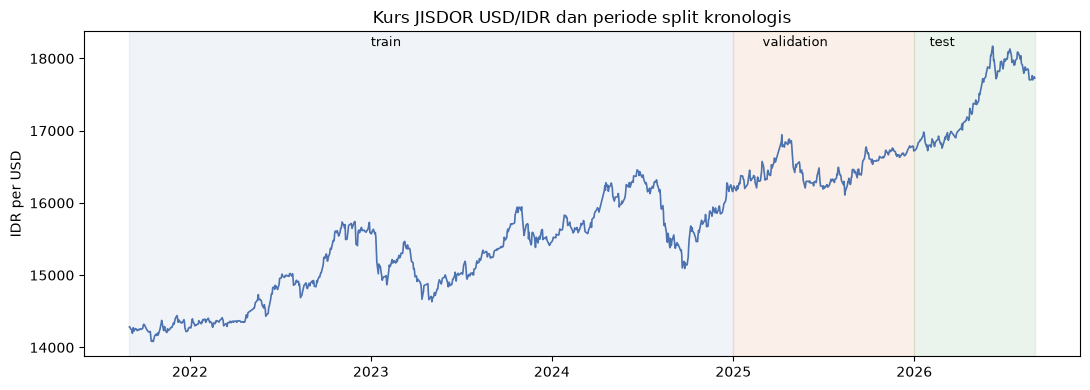

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily["trading_date"], daily["usd_idr_rate"], color="#4c72b0", linewidth=1.2)
ax.axvspan(daily["trading_date"].min(), pd.Timestamp(config.TRAIN_END), color="#4c72b0", alpha=0.08)
ax.axvspan(pd.Timestamp(config.TRAIN_END), pd.Timestamp(config.VALIDATION_END), color="#dd8452", alpha=0.12)
ax.axvspan(pd.Timestamp(config.VALIDATION_END), daily["trading_date"].max(), color="#55a868", alpha=0.12)
ax.text(pd.Timestamp("2023-01-01"), daily["usd_idr_rate"].max(), "train", fontsize=9)
ax.text(pd.Timestamp("2025-03-01"), daily["usd_idr_rate"].max(), "validation", fontsize=9)
ax.text(pd.Timestamp("2026-02-01"), daily["usd_idr_rate"].max(), "test", fontsize=9)
ax.set_title("Kurs JISDOR USD/IDR dan periode split kronologis")
ax.set_ylabel("IDR per USD")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_kurs_split.png", dpi=150)
plt.show()

## 3. Coverage berita dan aturan alignment

Berita dipetakan ke **hari perdagangan pertama setelah tanggal publikasi WIB** (`next_trading_day`). Tabel berikut memeriksa jarak hari publikasi ke hari perdagangan efektif; jarak >= 1 wajib hukumnya agar tidak ada look-ahead.

artikel: 14941
jarak hari (publikasi -> hari perdagangan efektif):
1     10262
2      1498
3      2375
4       366
5       202
6        70
7        52
8        40
9        13
10       17
11       37
12        9
semua efektif setelah publikasi: True


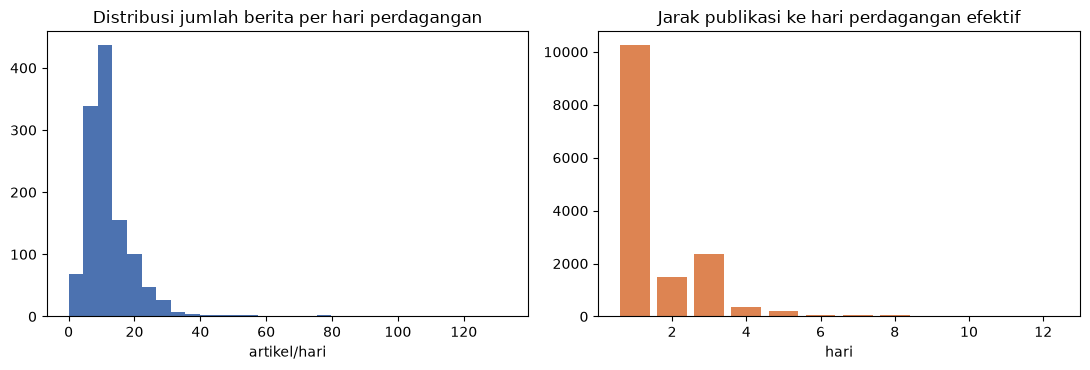

In [5]:
alignment = pd.read_csv(NEWS_ALIGNMENT_CSV, parse_dates=["publication_date", "effective_trading_date"])
lag = (alignment["effective_trading_date"] - alignment["publication_date"]).dt.days
print("artikel:", len(alignment))
print("jarak hari (publikasi -> hari perdagangan efektif):")
print(lag.value_counts().sort_index().to_string())
print("semua efektif setelah publikasi:", bool((lag >= 1).all()))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(daily["geopolitical_news_count"], bins=30, color="#4c72b0")
axes[0].set_title("Distribusi jumlah berita per hari perdagangan")
axes[0].set_xlabel("artikel/hari")
axes[1].bar(lag.value_counts().sort_index().index, lag.value_counts().sort_index().values, color="#dd8452")
axes[1].set_title("Jarak publikasi ke hari perdagangan efektif")
axes[1].set_xlabel("hari")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_berita.png", dpi=150)
plt.show()

baris terbuang (histori < 20 hari atau label hari berikutnya tidak ada): 21


,split,rows,date_start,date_end,up_ratio
0,train,790,2021-09-29,2024-12-31,0.562
1,validation,237,2025-01-02,2025-12-31,0.523
2,test,154,2026-01-02,2026-08-31,0.571


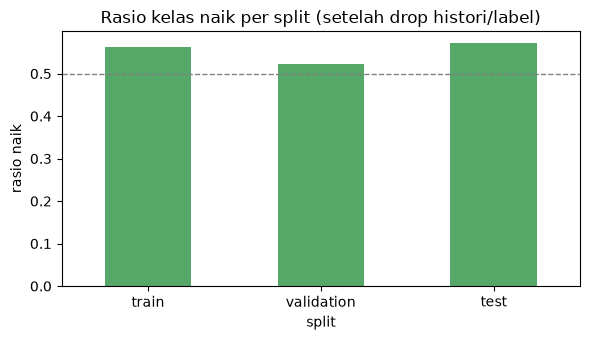

In [6]:
frame = data_preparation.build_modeling_frame()
train, validation, test = data_preparation.split_frame(frame)
summary = pd.DataFrame([
    data_preparation.summarize_split("train", train),
    data_preparation.summarize_split("validation", validation),
    data_preparation.summarize_split("test", test),
])
ax = summary.set_index("split")[["up_ratio"]].plot(kind="bar", figsize=(6, 3.5), legend=False, color="#55a868")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title("Rasio kelas naik per split (setelah drop histori/label)")
ax.set_ylabel("rasio naik")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_target_split.png", dpi=150)
summary

## 4. Temuan audit

- Kurs JISDOR mencakup **1.202 hari perdagangan** (1 Sep 2021 - 1 Sep 2026), tanpa duplikat tanggal; jeda terpanjang antar hari perdagangan 12 hari (cuti bersama Idul Fitri 2025), dan berita yang terbit selama libur panjang mengalir ke hari perdagangan berikutnya lewat aturan alignment.
- Terdapat **14.941 artikel** geopolitik yang semuanya berhasil dipetakan; coverage berita **1.201 dari 1.202 hari** (99,9%), rata-rata 12,4 artikel/hari, maksimum 133 artikel/hari.
- Aturan alignment memetakan berita ke hari perdagangan berikutnya: seluruh artikel memiliki jarak >= 1 hari dari publikasi WIB, sehingga cutoff informasi aman dari look-ahead.
- Setelah pembuangan 21 baris (20 baris awal tanpa histori rolling 20 hari + 1 baris terakhir tanpa label besok), tersisa **1.181 baris** dengan rasio kelas naik 56,2% (train), 52,3% (validation), 57,1% (test).
- Kelas cukup seimbang; akurasi tetap harus dibandingkan dengan baseline mayoritas dan metrik F1/AUC.